In [6]:
import os 
import numpy as np 
import matplotlib.pyplot as plt
import wfdb
import seaborn as sns

In [7]:
%matplotlib inline

In [8]:
plt.style.use('seaborn-v0_8')

In [9]:
DATA_DIR = os.path.join("ecg_ssl_research","data","raw","mitdb")
os.makedirs(DATA_DIR, exist_ok = True)

In [10]:
wfdb.dl_database("mitdb",DATA_DIR)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [11]:
print(os.listdir(DATA_DIR)[:10])

['209.hea', '221.hea', '213.dat', '207.dat', '118.atr', '124.atr', '119.atr', '212.dat', '220.hea', '234.hea']


In [12]:
record = wfdb.rdrecord(os.path.join(DATA_DIR, "100"))

print(record.p_signal.shape)
print(record.fs)

(650000, 2)
360


In [13]:
duration = 650000 / 360
print(duration)

1805.5555555555557


This means each record = ~30 mins of heart activity

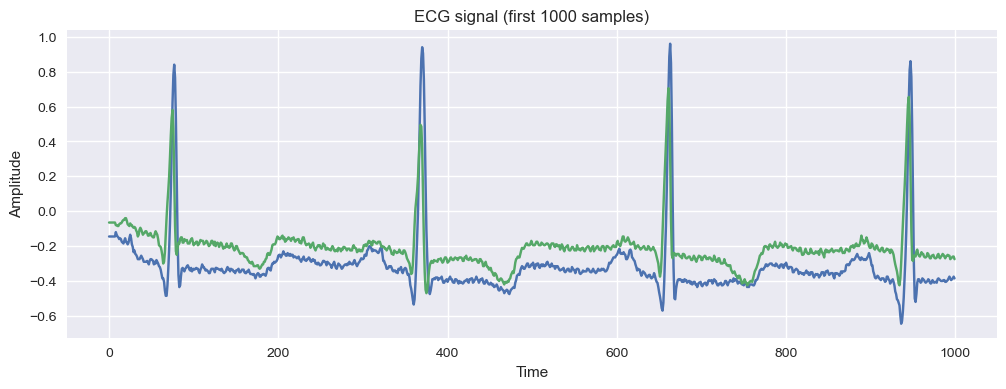

In [14]:
signal = record.p_signal

plt.figure(figsize = (12,4))
plt.plot(signal[:1000])
plt.title("ECG signal (first 1000 samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

1. Do you see clear repeating peaks?
ans -> yes 
3. Are peaks equally spaced?
ans -> they seem to appear after 300ms 
5. Does it look noisy?
ans -> yes

OBSERVATIONS : 
green line = channel 1
blue line = channel 2

In [15]:
annotation = wfdb.rdann(os.path.join(DATA_DIR, "100"),"atr")
print(annotation)
print(annotation.sample[:10]) 
print(annotation.symbol[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


annotaion.sample -> positions of heartbeats(indices)<br>
annotaion.symbol -> type of heartbeat


Common Symbols (VERY IMPORTANT)

| Symbol | Meaning |
| :--- | :--- |
| **N** | Normal beat |
| **V** | Ventricular ectopic beat (abnormal) |
| **A** | Atrial ectopic beat |
| **+** | Rhythm change marker (not a beat) |

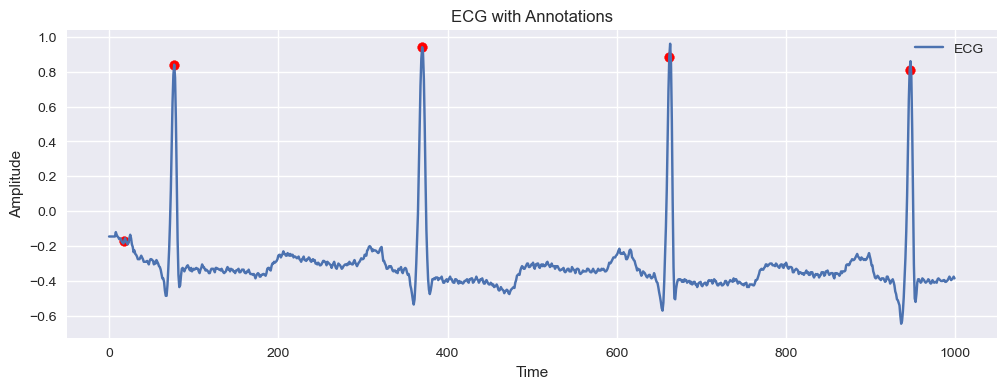

In [16]:
plt.figure(figsize=(12,4)) 

#plot signal 
plt.plot(signal[:1000,0],label="ECG")

#plot annotation points 
samples = annotation.sample
symbol = annotation.symbol

for i in range(len(samples)) : 
    if samples[i] < 1000 : 
        plt.scatter(samples[i], signal[samples[i],0], color='red')

plt.title("ECG with Annotations")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [17]:
valid_samples = []
valid_labels = []

for i in range(len(annotation.sample)) : 
    sym = annotation.symbol[i]

    if sym in ['N','A','V'] : 
        valid_samples.append(annotation.sample[i])
        valid_labels.append(sym)

In [18]:
print(valid_samples[:10])
print(valid_labels[:10])

[np.int64(77), np.int64(370), np.int64(662), np.int64(946), np.int64(1231), np.int64(1515), np.int64(1809), np.int64(2044), np.int64(2402), np.int64(2706)]
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N']


<br>
Right now we have full 30-min signal
<br>
But ML needs small chunks (one heartbeat at a time)
<br>
For each R-peak take a window around it

In [19]:
window_size = 180 # ~0.5 sec (since 360Hz)

beats = []
labels = []

for i in range(len(valid_samples)) : 
    center = valid_samples[i]

    start = center - window_size // 2
    end = center + window_size // 2 

    if start >= 0 and end < len(signal) : 
        beat = signal[start:end,0] #channel 1

        beats.append(beat) 
        labels.append(valid_labels[i])

In [20]:
print(len(beats))
print(beats[0].shape)

2271
(180,)


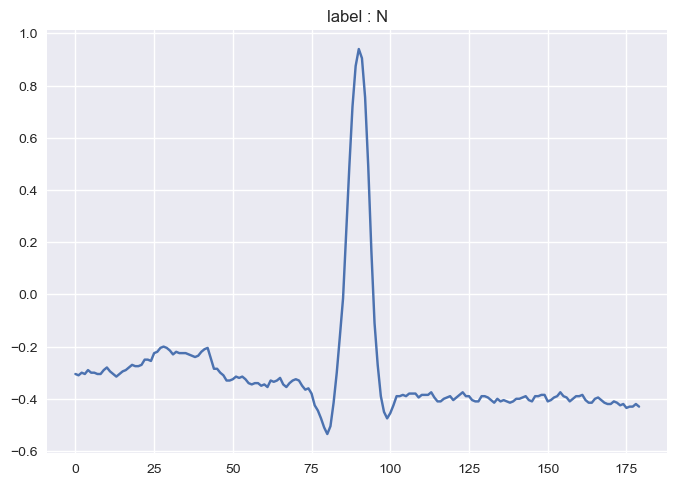

In [21]:
plt.plot(beats[0])
plt.title(f"label : {labels[0]}")
plt.show()

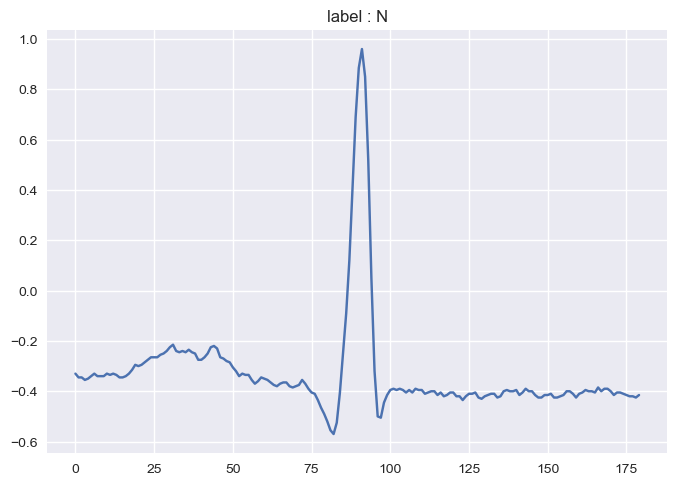

In [22]:
plt.plot(beats[1])
plt.title(f"label : {labels[1]}")
plt.show()

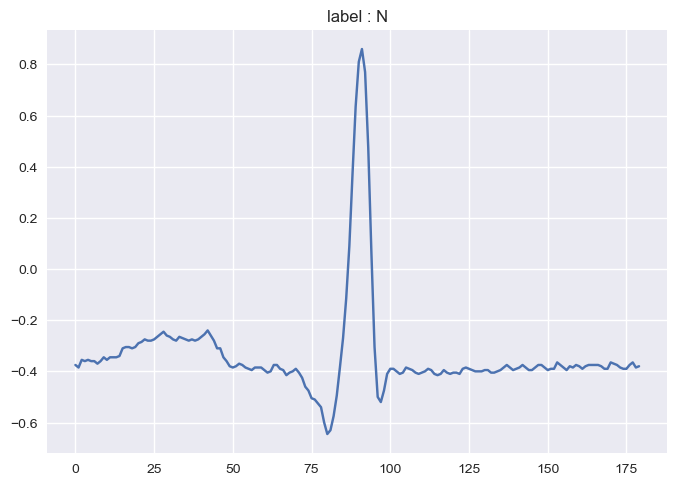

In [23]:
plt.plot(beats[2])
plt.title(f"label : {labels[2]}")
plt.show()

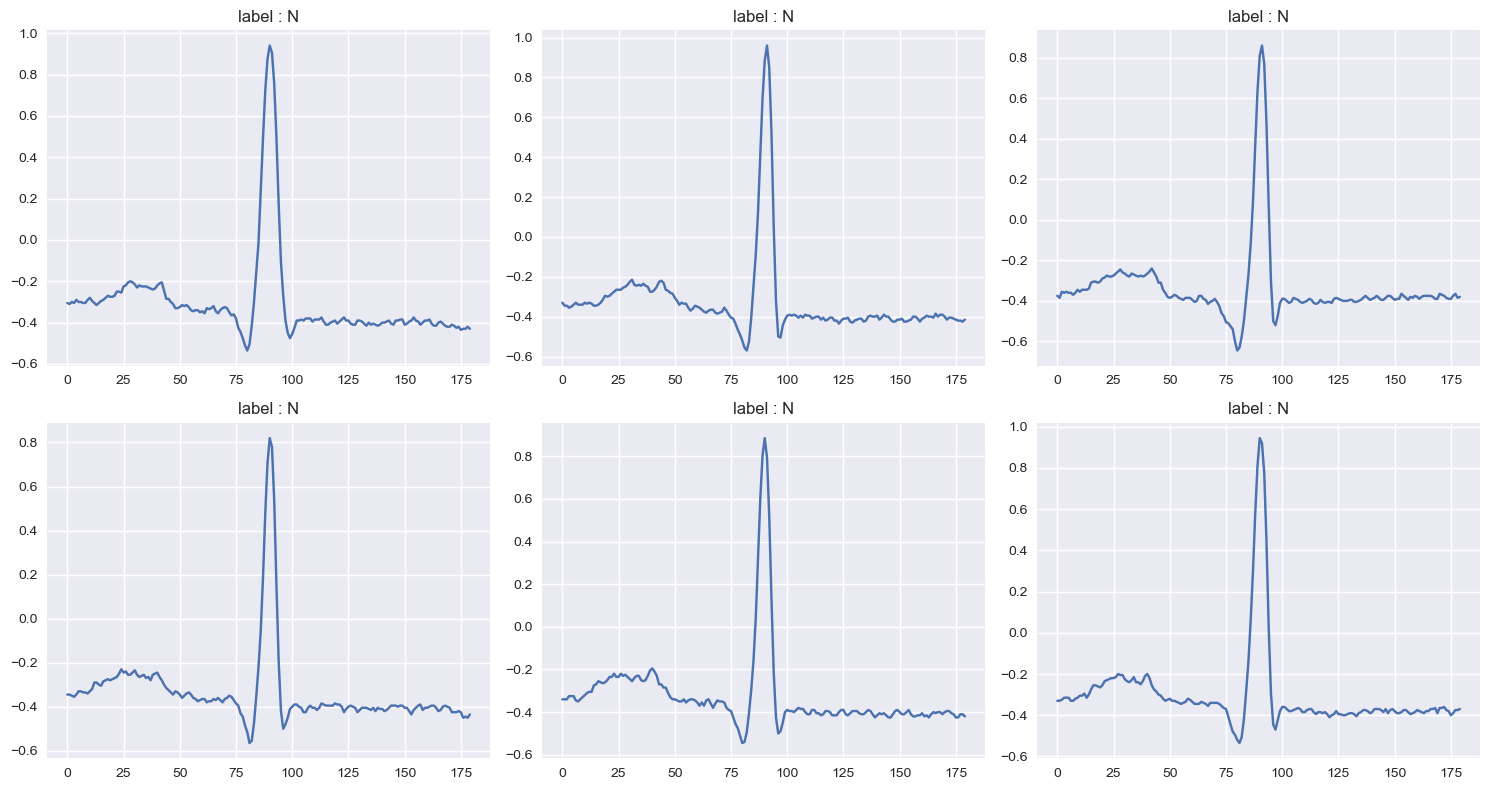

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

# Flatten the 2x3 axes array into a 1D array of 6 axes so we can easily loop through it
axes = axes.flatten()

# Loop through the first 6 beats and plot them on their respective subplots
for i in range(6):
    axes[i].plot(beats[i])
    axes[i].set_title(f"label : {labels[i]}")


plt.tight_layout()
plt.show()

What We Have Right Now
* 2272 beats
* shape = `(100,)`

---

Interpretation
* **2272 samples** → your dataset size
* **100 time points** → the length of each sample

So your dataset shape is:
**`(2272, 100)`**
**This is your X (features).**

And your labels:
**`labels`** → `['N', 'A', 'V', ...]`
**This is your Y (targets).**

In [25]:
label_map = {'N':0,'A':1,'V':2}
y = [label_map[l] for l in labels]

In [26]:
X = np.array(beats)
y = np.array(y)

print(X.shape, y.shape)

(2271, 180) (2271,)


In [27]:
X = (X - np.mean(X, axis=1, keepdims=True)) / np.std(X, axis=1, keepdims=True)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)